# Exercise 10-1: Create a linear regression

## Get the data

In [1]:
# Importing various libraries
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Step 3: Run the first three cells to read the data into the DataFrame named fish.

In [2]:
# Read the data into a datafram
fish = pd.read_csv('Fish.csv')

In [3]:
# Display the first 5 rows
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## Clean the data

### Step 5: Rename the Length1 column to VerticalLength, the Length2 column to DiagonalLength, and the Length3 column to CrossLength.

In [4]:
# Renaming columns in the 'fish' DataFrame
fish.rename(columns={'Length1':'VerticalLength', 
                     'Length2':'DiagonalLength', 
                     'Length3':'CrossLength'}, inplace=True)

## Identify a correlation

### Step 6: Use the corr() method to view how other columns correlate with the Weight column.

In [5]:
# Calculating the correlation coefficients between 'Weight' and all other columns in the DataFrame
fish.corr()[['Weight']]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10536\4285731780.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  fish.corr()[['Weight']]


,Weight
Weight,1.000000
VerticalLength,0.915712
DiagonalLength,0.918618
CrossLength,0.923044
Height,0.724345
Width,0.886507


### Step 7: Create a heatmap that shows how other columns correlate with the Weight column.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10536\262635295.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data=fish.corr(), annot=True, cmap='Blues')


<Axes: >

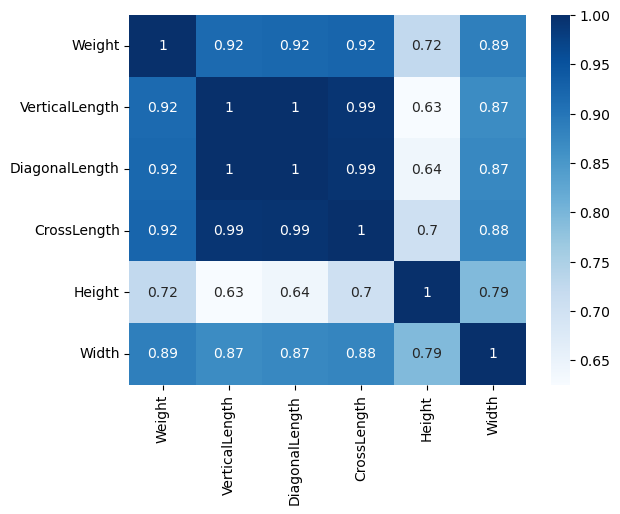

In [6]:
# Create a heatmap visualization of the correlation matrix for the 'fish' dataset using the seaborn library.
sns.heatmap(data=fish.corr(), annot=True, cmap='Blues')

### Step 8: Create a scatter plot that shows the relationship between the Weight and VerticalLength columns for all fish.

C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


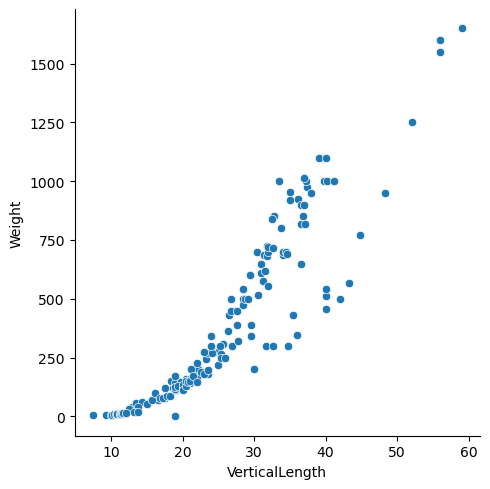

In [7]:
# Create a relational plot to visualize the relationship between 'VerticalLength' and 'Weight' columns in the 'fish' dataset using seaborn
sns.relplot(data=fish, x='VerticalLength', y='Weight')

### Step 9: Create the same scatter plot as the previous step, but use color to identify the data for each species.

C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


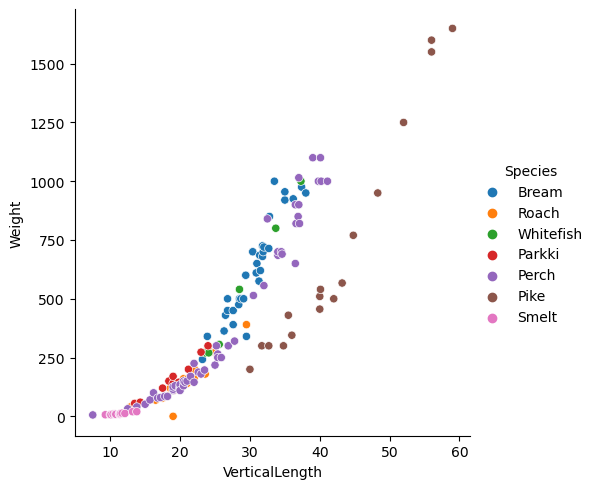

In [8]:
# Create a relational plot to visualize the relationship between 'VerticalLength' and 'Weight' columns
sns.relplot(data=fish, x='VerticalLength', y='Weight', hue='Species')

### Step 10: Create the same scatter plot as the previous step, but only plot the data for the species named Bream.

C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


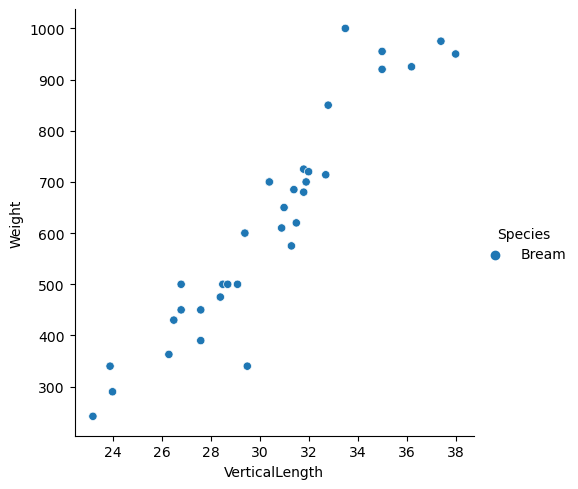

In [9]:
# Create a relational plot to visualize the relationship between 'VerticalLength' and 'Weight' columns
sns.relplot(data=fish.query('Species == "Bream"'), 
            x='VerticalLength', y='Weight', hue='Species')

## Create a linear model

### Step 12:  Filter the DataFrame so it only contains the values for the Bream species, and assign the resulting DataFrame to a variable named bream.

In [10]:
# Filter the 'fish' dataset to only include rows where the 'Species' is 'Bream'
bream = fish.query('Species == "Bream"')

### Step 13: Use the train_test_split() method to split the training and testing data for the Bream species data.

In [11]:
# Split the 'bream' dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    bream[['VerticalLength']], bream[['Weight']])

### Step 14: Create the model and fit the training data.

In [12]:
# Create an instance of the LinearRegression model
model = LinearRegression()

# Fit the linear regression model on the training data
model.fit(x_train, y_train)

LinearRegression()

### Step 15: Score the testing data.

In [13]:
# Evaluate the performance of the linear regression model on the test data
model.score(x_test, y_test)

0.5549204455206874

### Step 16: Make the predictions and store the results in a DataFrame. 

In [14]:
# Use the trained linear regression model to make predictions on the test data
y_predicted = model.predict(x_test)

# Create a pandas DataFrame to store the predicted weights
predicted = pd.DataFrame(y_predicted, columns = ['PredictedWeight'])

## Plot the regression line

### Step 17: Join the column for the predicted data with the columns for the original data, and assign the resulting DataFrame to a variable named final.

In [15]:
# Join the predicted weights with the actual feature and target values from the test set
final = predicted.join([x_test.reset_index(drop=True),
                        y_test.reset_index(drop=True)])
final.head()

,PredictedWeight,VerticalLength,Weight
0,420.113655,26.3,363.0
1,669.909489,31.0,650.0
2,531.724560,28.4,475.0
3,638.020659,30.4,700.0
4,696.483514,31.5,620.0


In [16]:
# rename the Weight column to indicate that it stores actual values, not predicted values
final.rename(columns={'Weight':'ActualWeight'}, inplace=True)
final.head()

,PredictedWeight,VerticalLength,ActualWeight
0,420.113655,26.3,363.0
1,669.909489,31.0,650.0
2,531.724560,28.4,475.0
3,638.020659,30.4,700.0
4,696.483514,31.5,620.0


### Step 18: Melt the actual and predicted values into columns named Variable and Value, and assign the resulting DataFrame to a variable named finalMelt.

In [17]:
# Melt the final DataFrame to create a long format for plotting
finalMelt = pd.melt(final, id_vars=['VerticalLength'], 
                    value_vars=['ActualWeight','PredictedWeight'], 
                    var_name='Variable', value_name='Value')
finalMelt.head()

,VerticalLength,Variable,Value
0,26.3,ActualWeight,363.0
1,31.0,ActualWeight,650.0
2,28.4,ActualWeight,475.0
3,30.4,ActualWeight,700.0
4,31.5,ActualWeight,620.0


### Step 19: Use the relplot() method to create a scatter plot that plots the actual and predicted values. Make sure to use a different color for actual and predicted values.

C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


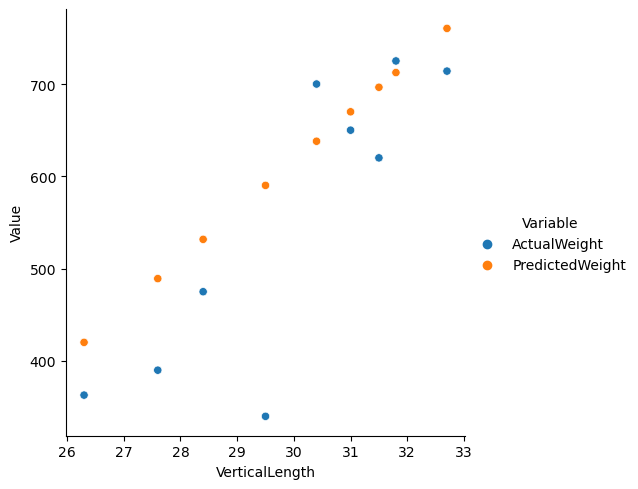

In [18]:
# Create a relational plot to visualize the actual and predicted weights against the 'VerticalLength' feature
sns.relplot(data=finalMelt, x='VerticalLength', y='Value', hue='Variable')

### Step 20: Use the lmplot() method to produce a similar plot.

C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


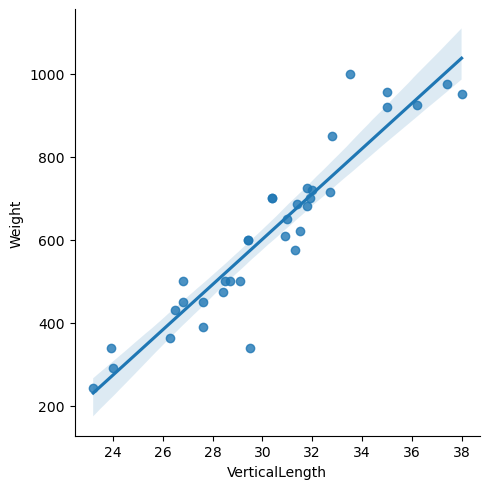

In [19]:
# Create a scatter plot with a fitted regression line to visualize the relationship between 'VerticalLength' and 'Weight'
sns.lmplot(data=bream, x='VerticalLength', y='Weight')

## Plot the residuals

### Step 21: Calculate the residuals and add them as a new column in the DataFrame named final.

In [20]:
# Calculate the residuals and add it as a column to the 'final' DataFrame
final['Residuals'] = final.ActualWeight - final.PredictedWeight

### Step 22: Use relplot() to create a scatter plot that plots the residuals, and use the axhline() method to improve your plot.

C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


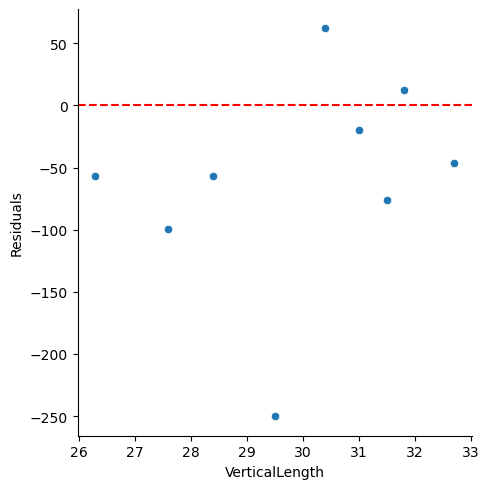

In [21]:
# Create a relational plot to visualize the residuals against the 'VerticalLength' feature
g = sns.relplot(data=final, x='VerticalLength', y='Residuals')
for ax in g.axes.flat:
    ax.axhline(0, ls='--', color='red')

### Step 23: Use the residplot() method to produce a similar plot.

<Axes: xlabel='VerticalLength', ylabel='Weight'>

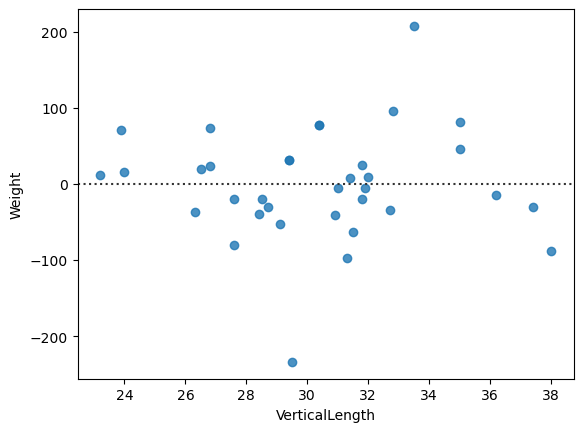

In [22]:
# Create a residual plot to visualize the residuals against the 'VerticalLength' feature for the 'Bream' species
sns.residplot(data=bream, x='VerticalLength', y='Weight')